<a href="https://colab.research.google.com/github/sandeep7348/Assignment/blob/master/RegionGrow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving INPUT2.jpeg to INPUT2 (1).jpeg


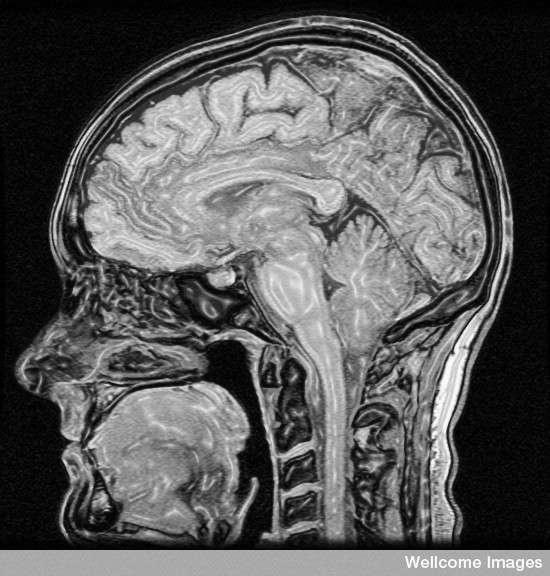

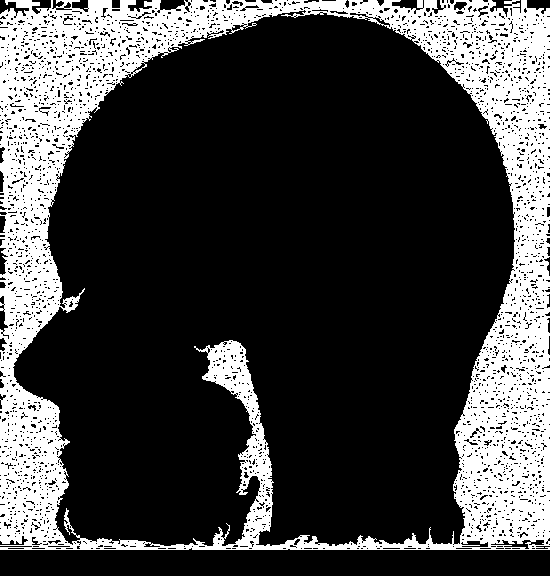

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files


def load_image():
    uploaded = files.upload()
    path = list(uploaded.keys())[0]
    img = cv2.imread(path, 0)
    return img


def initialize_segmentation(image, seed):
    h, w = image.shape
    segmented = np.zeros((h, w), dtype=np.uint8)
    segmented[seed[0], seed[1]] = 255
    return segmented


def get_neighbors():
    return [(-1, -1), (-1, 0), (-1, 1),
            (0, -1),          (0, 1),
            (1, -1), (1, 0),  (1, 1)]


def region_growing(image, seed, threshold):
    segmented = initialize_segmentation(image, seed)
    stack = [seed]
    neighbors = get_neighbors()

    seed_value = image[seed[0], seed[1]]
    h, w = image.shape

    while stack:
        x, y = stack.pop()

        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy

            if 0 <= nx < h and 0 <= ny < w:
                if segmented[nx, ny] == 0:
                    if abs(int(image[nx, ny]) - int(seed_value)) < threshold:
                        segmented[nx, ny] = 255
                        stack.append((nx, ny))

    return segmented


def display_results(original, segmented):
    cv2_imshow(original)
    cv2_imshow(segmented)


def main():
    image = load_image()

    seed_point = (100, 100)
    threshold = 10

    result = region_growing(image, seed_point, threshold)
    display_results(image, result)


main()